# Лабораторная работа
### Маклаков Артём Б05-332
## Кубический свободный сплайн

### 1 Цель работы
Целью лабораторной работы является реализация алгоритма построения свободного кубического сплайна для таблично заданной функции и анализ качества аппроксимации на равномерной и неравномерной сетках.

### 2 Теоретическая часть
Свободный кубический сплайн строится на отрезке $[x_0, x_n]$ и удовлетворяет граничным условиям
$$S''(x_0)=0, \qquad S''(x_n)=0.$$


In [116]:
import numpy as np
import matplotlib.pyplot as plt

### 2.1 Метод прогонки
Для трехдиагональной системы
$$
\begin{aligned}
&b_1x_1+c_1x_2=f_1,\\
&a_kx_{k-1}+b_kx_k+c_kx_{k+1}=f_k,\quad k=2,\dots,n-1,\\
&a_nx_{n-1}+b_nx_n=f_n,
\end{aligned}
$$
используется метод прогонки, состоящий из прямого и обратного хода.

**Прямой ход (прогоночные коэффициенты):**
$$
p_1=\frac{c_1}{b_1},\qquad r_1=\frac{f_1}{b_1},
$$
$$
p_k=\frac{c_k}{b_k-a_kp_{k-1}},\qquad
r_k=\frac{f_k-a_kr_{k-1}}{b_k-a_kp_{k-1}},\quad k=2,\dots,n-1,
$$
$$
x_n=\frac{f_n-a_nr_{n-1}}{b_n-a_np_{n-1}}
$$

**Обратный ход:**
$$
x_k=r_k-p_kx_{k+1},\quad k=n-1,\dots,1.
$$

В реализации `solveTridiagonal` используются те же обозначения (`p`, `r`), а индексация массивов записана в Python-форме (с нуля).


In [117]:
def solveTridiagonal(a, b, c, f):
    n = len(f)

    p = np.zeros(n, dtype=float)
    r = np.zeros(n, dtype=float)
    x = np.zeros(n, dtype=float)

    p[0] = c[0] / b[0]
    r[0] = f[0] / b[0]

    for k in range(1, n):
        denominator = b[k] - a[k] * p[k - 1]

        if k < n - 1:
            p[k] = c[k] / denominator
        r[k] = (f[k] - a[k] * r[k - 1]) / denominator

    x[n - 1] = r[n - 1]

    for k in range(n - 2, -1, -1):
        x[k] = r[k] - p[k] * x[k + 1]

    return x


### 2.2 Построение коэффициентов свободного кубического сплайна
На каждом отрезке $[x_i, x_{i+1}]$ задается полином
$$S_i(x)=a_i+b_i(x-x_i)+c_i(x-x_i)^2+d_i(x-x_i)^3.$$

Обозначим
$$h_i=x_{i+1}-x_i, \qquad m_i=S''(x_i).$$

Из выражения
$$S_i''(x)=2c_i+6d_i(x-x_i)$$
получаем
$$c_i=\frac{m_i}{2}, \qquad d_i=\frac{m_{i+1}-m_i}{6h_i}.$$

Из условий интерполяции $S_i(x_i)=f_i$ и $S_i(x_{i+1})=f_{i+1}$ следует
$$a_i=f_i, \qquad b_i=\frac{f_{i+1}-f_i}{h_i}-\frac{h_i(2m_i+m_{i+1})}{6}.$$

Для внутренних узлов из условия непрерывности первой производной получаем систему на $m_i$:
$$h_{i-1}m_{i-1}+2(h_{i-1}+h_i)m_i+h_i m_{i+1}=6\left(\frac{f_{i+1}-f_i}{h_i}-\frac{f_i-f_{i-1}}{h_{i-1}}\right), \quad i=1,\dots,n-1,$$
с граничными условиями
$$m_0=0, \qquad m_n=0.$$

Полученная система является трехдиагональной и решается методом прогонки.


In [118]:
def buildSpline(x, f):
    x = np.array(x, dtype=float)
    f = np.array(f, dtype=float)

    n = len(x) - 1

    for i in range(n):
        if x[i] >= x[i + 1]:
            raise ValueError('узлы должны быть строго возрастающими')

    h = np.zeros(n, dtype=float)
    for i in range(n):
        h[i] = x[i + 1] - x[i]

    m = np.zeros(n + 1, dtype=float)

    if n > 1:
        lower = np.zeros(n - 1, dtype=float)
        diag = np.zeros(n - 1, dtype=float)
        upper = np.zeros(n - 1, dtype=float)
        rhs = np.zeros(n - 1, dtype=float)

        for i in range(1, n):
            row = i - 1

            if row > 0:
                lower[row] = h[i - 1]
            diag[row] = 2.0 * (h[i - 1] + h[i])
            if row < n - 2:
                upper[row] = h[i]

            rhs[row] = 6.0 * ((f[i + 1] - f[i]) / h[i] - (f[i] - f[i - 1]) / h[i - 1])

        m_inner = solveTridiagonal(lower, diag, upper, rhs)
        for i in range(1, n):
            m[i] = m_inner[i - 1]

    a_coef = np.zeros(n, dtype=float)
    b_coef = np.zeros(n, dtype=float)
    c_coef = np.zeros(n, dtype=float)
    d_coef = np.zeros(n, dtype=float)

    for i in range(n):
        a_coef[i] = f[i]
        b_coef[i] = (f[i + 1] - f[i]) / h[i] - h[i] * (2.0 * m[i] + m[i + 1]) / 6.0
        c_coef[i] = 0.5 * m[i]
        d_coef[i] = (m[i + 1] - m[i]) / (6.0 * h[i])

    return a_coef, b_coef, c_coef, d_coef


### 2.3 Вычисление значения сплайна в заданной точке
Для заданной точки определяется интервал $[x_i, x_{i+1}]$, после чего значение сплайна вычисляется по формуле
$$S_i(x)=a_i+b_i t+c_i t^2+d_i t^3, \qquad t=x-x_i.$$


In [119]:
def splineValue(x, a, b, c, d, point):
    n = len(x) - 1

    if point < x[0] or point > x[n]:
        raise ValueError('Точка вне отрезка интерполяции')

    interval = n - 1
    for i in range(n):
        if x[i] <= point <= x[i + 1]:
            interval = i
            break

    t = point - x[interval]
    return a[interval] + b[interval] * t + c[interval] * t * t + d[interval] * t * t * t


### 3 Реализация
#### 3.1 Требования к программе
1. Программа должна содержать функцию, которая принимает на вход массив координат узлов $[x_0,\dots,x_n]$ и массив значений функции $f$ в этих узлах.
2. Функция должна вычислять коэффициенты свободного кубического сплайна на каждом из отрезков. Для решения трехдиагональной системы относительно коэффициентов должна использоваться функция, реализующая метод прогонки.
3. Программа должна содержать функцию, которая вычисляет значение кубического сплайна в заданной точке.
4. Программа должна вызывать реализованные функции для равномерной и неравномерной сеток и тестовой функции, а также строить на одном рисунке график исходной функции, интерполяционного сплайна и значения в точках интерполяции.

#### 3.2 Алгоритм
1. Вход: массив узлов $x=[x_0,\dots,x_n]$ и массив значений $f=[f_0,\dots,f_n]$.
2. Проверка корректности узлов: $x_i < x_{i+1}$ для всех $i$.
3. Вычисление шагов сетки: $h_i=x_{i+1}-x_i$, $i=0,\dots,n-1$.
4. Формирование трехдиагональной системы для внутренних $m_i=S''(x_i)$, $i=1,\dots,n-1$, с условиями свободного сплайна $m_0=0$, $m_n=0$.
5. Решение системы методом прогонки и восстановление массива $m$.
6. Вычисление коэффициентов на каждом отрезке:
   $a_i=f_i$, $b_i=\frac{f_{i+1}-f_i}{h_i}-\frac{h_i(2m_i+m_{i+1})}{6}$, $c_i=\frac{m_i}{2}$, $d_i=\frac{m_{i+1}-m_i}{6h_i}$.
7. Для заданной точки: выбор интервала $[x_i, x_{i+1}]$, вычисление $t=x-x_i$, подстановка в $S_i(x)=a_i+b_it+c_it^2+d_it^3$.

#### 3.3 Тестовая функция
Для численного эксперимента используется функция
$$f(x)=\frac{1}{1+25x^2}.$$


In [120]:
def testFunction(x):
    return 1 / (1 + 25 * x * x)


#### 3.4 Основной запуск
Выполняется построение сплайна для равномерной и неравномерной сеток, вычисление значений на плотной сетке и построение сравнительных графиков.


Неравномерная сетка:
[0.         1.58248317 2.14301796 2.32116843 2.6181441  3.35941009
 4.        ]


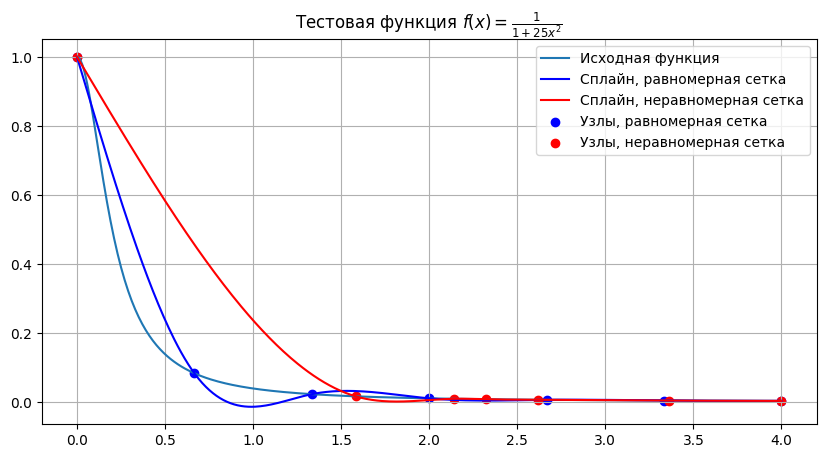

In [143]:
def testRun():
    x_uniform = np.linspace(0.0, 4.0, 7)
    f_uniform = testFunction(x_uniform)

    inner_points = np.random.uniform(0.1, 3.9, 5)
    inner_points.sort()

    x_nonuniform = np.concatenate(([0.0], inner_points, [4.0]))
    f_nonuniform = testFunction(x_nonuniform)

    print('Неравномерная сетка:')
    print(x_nonuniform)

    a1, b1, c1, d1 = buildSpline(x_uniform, f_uniform)
    a2, b2, c2, d2 = buildSpline(x_nonuniform, f_nonuniform)

    x_plot = np.linspace(0.0, 4.0, 400)
    y_true = np.zeros(len(x_plot), dtype=float)
    y_spline_uniform = np.zeros(len(x_plot), dtype=float)
    y_spline_nonuniform = np.zeros(len(x_plot), dtype=float)

    for i in range(len(x_plot)):
        y_true[i] = testFunction(x_plot[i])
        y_spline_uniform[i] = splineValue(x_uniform, a1, b1, c1, d1, x_plot[i])
        y_spline_nonuniform[i] = splineValue(x_nonuniform, a2, b2, c2, d2, x_plot[i])

    plt.figure(figsize=(10, 5))
    plt.plot(x_plot, y_true, label='Исходная функция')
    plt.plot(x_plot, y_spline_uniform, label='Сплайн, равномерная сетка', color='blue')
    plt.plot(x_plot, y_spline_nonuniform, label='Сплайн, неравномерная сетка', color='red')
    plt.scatter(x_uniform, f_uniform, label='Узлы, равномерная сетка', color='blue')
    plt.scatter(x_nonuniform, f_nonuniform, label='Узлы, неравномерная сетка', color='red')
    plt.title("Тестовая функция $f(x)=\\frac{1}{1 + 25 x^2}$")
    plt.legend()
    plt.grid(True)
    plt.show()

testRun()


#### 3.5 Анализ результатов (первая неравномерная сетка)
При смещении узлов неравномерной сетки вправо точность аппроксимации на отдельных участках оказывается ниже по сравнению с равномерной сеткой.


Неравномерная сетка:
[0.         0.34997269 0.54675428 0.76360627 0.81601287 2.2370819
 4.        ]


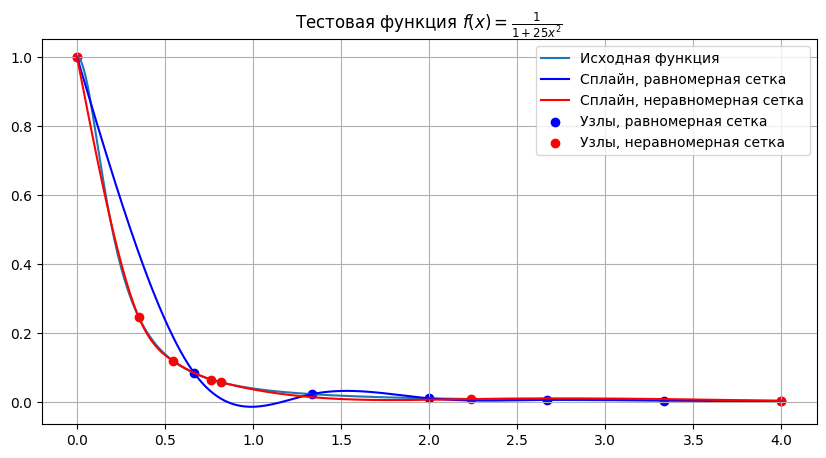

In [152]:
testRun()

#### 3.6 Анализ результатов (вторая неравномерная сетка)
После изменения распределения узлов качество аппроксимации на неравномерной сетке улучшается и становится сопоставимым или выше, чем на равномерной сетке. Можно увидеть, что функция интерполируется заметно лучше когда большее число точек расположены ключевых местах графика функции.


### 4 Выводы
1. Реализовано построение свободного кубического сплайна с условиями $S''(x_0)=0$ и $S''(x_n)=0$.
2. Реализован метод прогонки для решения трехдиагональной системы при вычислении коэффициентов сплайна.
3. Реализована функция вычисления значения сплайна в произвольной точке отрезка интерполяции.
4. Проведено сравнение аппроксимации на равномерной и двух вариантах неравномерной сетки.
5. Показано, что качество интерполяции на неравномерной сетке существенно зависит от распределения узлов.
